<a href="https://colab.research.google.com/github/halimaturrohmah-hub/Halimatur-Rohmah/blob/main/Tugas_4_%E2%80%93_Clustering_Customer_Personality_Analysis_Matur.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

2. Load Dataset

In [ ]:
df = pd.read_csv('/content/sample_data/marketing_campaign.csv', sep='\t')

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


3. Data Preprocessing

Cek Missing Value

In [ ]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


Hapus Missing Value

In [ ]:
df = df.dropna()

Hapus Kolom yang Tidak Digunakan

In [ ]:
df = df.drop(['ID'], axis=1)

Ubah Tanggal Menjadi Datetime

In [ ]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

Membuat Umur

In [ ]:
df['Age'] = 2025 - df['Year_Birth']

4. Feature Selection

Fokus pada fitur numerik.

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.head()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
0,1957,58138.0,0,0,58,635,88,546,172,88,...,0,0,0,0,0,0,3,11,1,68
1,1954,46344.0,1,1,38,11,1,6,2,1,...,0,0,0,0,0,0,3,11,0,71
2,1965,71613.0,0,0,26,426,49,127,111,21,...,0,0,0,0,0,0,3,11,0,60
3,1984,26646.0,1,0,26,11,4,20,10,3,...,0,0,0,0,0,0,3,11,0,41
4,1981,58293.0,1,0,94,173,43,118,46,27,...,0,0,0,0,0,0,3,11,0,44


5. Normalisasi Data

In [ ]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(numeric_df)

6. Dimension Reduction (PCA)

Karena jumlah fitur banyak.

In [ ]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(
    data=pca_data,
    columns=['PC1','PC2']
)

pca_df.head()

,PC1,PC2
0,3.831664,0.238113
1,-2.268605,1.478745
2,1.638753,0.261406
3,-2.626793,-1.903823
4,-0.549756,-1.066816


7. Menentukan Jumlah Cluster (Elbow Method)

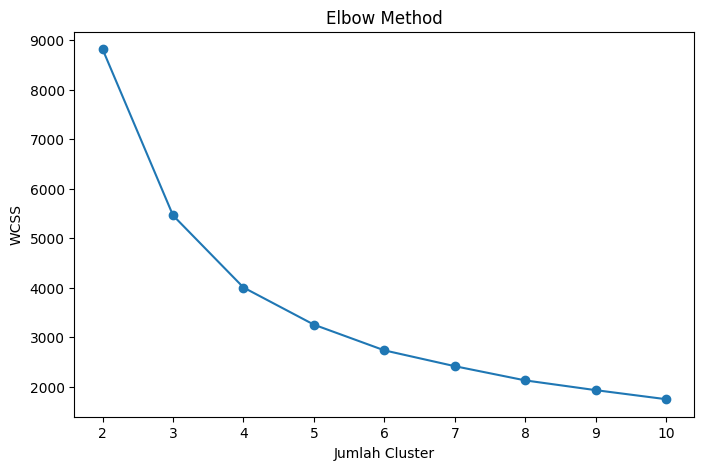

In [ ]:
wcss = []

for i in range(2,11):
    kmeans = KMeans(n_clusters=i,
                    random_state=42,
                    n_init=10)

    kmeans.fit(pca_data)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker='o')
plt.xlabel('Jumlah Cluster')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

8. Membuat Model Clustering

Misal hasil elbow terbaik = 4 cluster.

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster = kmeans.fit_predict(pca_data)

pca_df['Cluster'] = cluster

9. Evaluasi Model

In [ ]:
score = silhouette_score(
    pca_data,
    cluster
)

print("Silhouette Score:", score)

Silhouette Score: 0.42306728768236374


10. Visualisasi Cluster

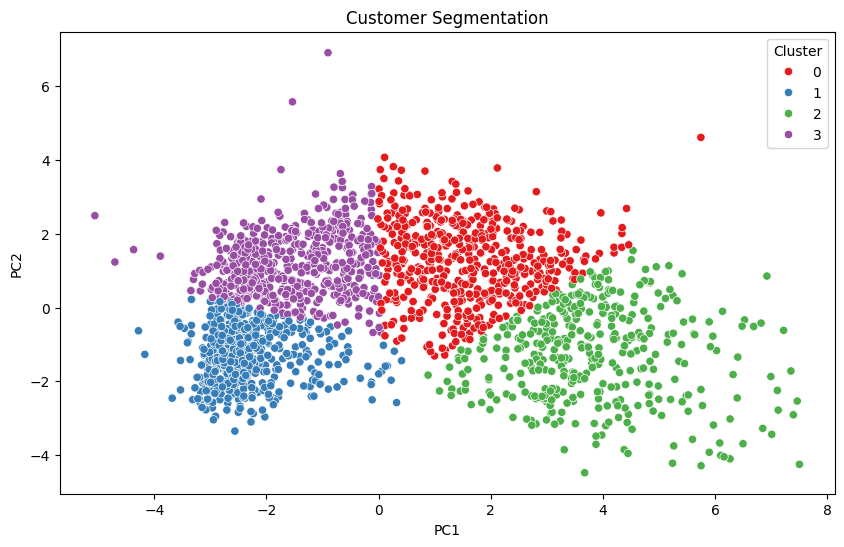

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1'
)

plt.title('Customer Segmentation')
plt.show()

11. Customer Segmentation

Gabungkan kembali label cluster.

In [ ]:
numeric_df['Cluster'] = cluster

segment = numeric_df.groupby('Cluster').mean()

segment

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1961.879182,64458.401487,0.087361,0.763941,49.148699,548.455390,37.224907,218.260223,50.451673,38.579926,...,0.068773,0.131970,0.033457,0.026022,0.014870,0.011152,3.0,11.0,0.118959,63.120818
1,1978.554348,31873.032609,0.886646,0.155280,47.507764,35.319876,6.271739,26.636646,8.891304,6.152174,...,0.099379,0.001553,0.000000,0.001553,0.000000,0.012422,3.0,11.0,0.122671,46.445652
2,1972.210280,79210.261682,0.046729,0.105140,49.030374,644.626168,71.778037,491.401869,105.002336,73.705607,...,0.098131,0.151869,0.336449,0.287383,0.046729,0.002336,3.0,11.0,0.357477,52.789720
3,1962.244224,44014.957096,0.562706,0.930693,50.478548,135.920792,5.970297,41.526403,9.232673,5.993399,...,0.033003,0.044554,0.000000,0.006601,0.003300,0.009901,3.0,11.0,0.061056,62.755776
